In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# from Step 2
input_checkpoint = "ready_for_prediction.csv"

if not os.path.exists(input_checkpoint):
    print("Error: 'ready_for_prediction.csv' is missing.")
else:
    ready_df = pd.read_csv(input_checkpoint)
    
    # Enforce strict standardization: string cast, strip whitespace, and normalize case
    ready_df['rsid_clean'] = ready_df['rsid'].astype(str).str.strip().str.lower()
    
    # Instantiate highly optimized hash set for rapid stream-matching operations
    target_rsids = set(ready_df['rsid_clean'].tolist())
    
    print("Input Checkpoint Successfully Operational.")
    print(f"   Hash set constructed containing {len(target_rsids)} clean search keys.")
    print(f"   Active hardware search space tracking: {ready_df['rsid'].nunique()} unique rsIDs across {len(ready_df)} functional alleles.")

Input Checkpoint Successfully Operational.
   Hash set constructed containing 40 clean search keys.
   Active hardware search space tracking: 40 unique rsIDs across 42 functional alleles.


In [3]:
bulk_file = "hg_utrsnp_gainloss.tsv"

if not os.path.exists(bulk_file):
    print(f"Error: Target bulk file '{bulk_file}' absent from local path.")
else:
    
    CHUNK_SIZE = 100000  
    matched_chunks = []
    total_rows_scanned = 0
    
    print(f"Streaming '{bulk_file}' in chunks of {CHUNK_SIZE:,}...")
    
    # Establish iterative stream connection to file system
    chunks_stream = pd.read_csv(
        bulk_file, 
        sep='\t', 
        chunksize=CHUNK_SIZE, 
        low_memory=False, 
        on_bad_lines='skip'
    )
    
    # Extract structural header data from the initial buffer block to determine database layouts
    first_chunk = next(chunks_stream)
    bulk_snp_col = 'snp_id' if 'snp_id' in first_chunk.columns else ('rsid' if 'rsid' in first_chunk.columns else first_chunk.columns[0])
    print(f" Database Column Schema Detected. Mapping column '{bulk_snp_col}' as primary lookup index.")
    
    # Evaluate Chunk 1 manually
    first_chunk['bulk_rsid_clean'] = first_chunk[bulk_snp_col].astype(str).str.strip().str.lower()
    matched_first = first_chunk[first_chunk['bulk_rsid_clean'].isin(target_rsids)]
    if not matched_first.empty:
        matched_chunks.append(matched_first)
    total_rows_scanned += len(first_chunk)
    
    # Loop iteratively through the remaining chunks of the open file stream
    for idx, chunk in enumerate(chunks_stream, start=2):
        total_rows_scanned += len(chunk)
        
        # In-place clean for comparison matching
        chunk['bulk_rsid_clean'] = chunk[bulk_snp_col].astype(str).str.strip().str.lower()
        
        # Apply instantaneous localized filtering before memory aggregation
        filtered_chunk = chunk[chunk['bulk_rsid_clean'].isin(target_rsids)]
        
        if not filtered_chunk.empty:
            matched_chunks.append(filtered_chunk)
            
        # Logging check-points for every 10 million records to verify active processing
        if total_rows_scanned % 10000000 == 0:
            print(f"   Scanned {total_rows_scanned:,} rows... Found matches so far.")
    
    print("\n" + "="*50)
    print("DATABASE SCAN COMPLETED")
    print(f"Successfully processed all {total_rows_scanned:,} source rows.")
    print(f"Total matching raw hits retained in buffer list: {len(matched_chunks)}")
    print("="*50)

Streaming 'hg_utrsnp_gainloss.tsv' in chunks of 100,000...
 Database Column Schema Detected. Mapping column 'SNP_ID' as primary lookup index.
   Scanned 10,000,000 rows... Found matches so far.
   Scanned 20,000,000 rows... Found matches so far.
   Scanned 30,000,000 rows... Found matches so far.
   Scanned 40,000,000 rows... Found matches so far.
   Scanned 50,000,000 rows... Found matches so far.
   Scanned 60,000,000 rows... Found matches so far.
   Scanned 70,000,000 rows... Found matches so far.
   Scanned 80,000,000 rows... Found matches so far.
   Scanned 90,000,000 rows... Found matches so far.
   Scanned 100,000,000 rows... Found matches so far.
   Scanned 110,000,000 rows... Found matches so far.
   Scanned 120,000,000 rows... Found matches so far.
   Scanned 130,000,000 rows... Found matches so far.
   Scanned 140,000,000 rows... Found matches so far.
   Scanned 150,000,000 rows... Found matches so far.
   Scanned 160,000,000 rows... Found matches so far.
   Scanned 170,000,

In [5]:
print("Columns in ready_df:", ready_df.columns)
print("Sample genes in ready_df:", ready_df['Gene_Name'].dropna().head(10))

Columns in ready_df: Index(['rsid', 'Gene_ID', 'Gene_Name', 'Consequence', 'Gene stable ID',
       '3' UTR start', '3' UTR end', 'utr_length', 'Allele_Sequence',
       'rsid_clean'],
      dtype='str')
Sample genes in ready_df: 1              OPA3
2     EIF5AP3,NKPD1
6              COQ7
7             TREM2
8             RAB29
13       Intergenic
14       Intergenic
15           SAP30L
17       Intergenic
18             APOE
Name: Gene_Name, dtype: str


In [6]:
if matched_chunks:
    all_matches_df = pd.concat(matched_chunks, ignore_index=True)
    
    print(" Initializing relational table join back to candidate metadata...")
    final_prediction_df = pd.merge(
        ready_df,
        all_matches_df,
        left_on='rsid_clean',
        right_on='bulk_rsid_clean',
        how='inner'
    )
    
    # Purge proxy cleaning headers to match standard publication formatting
    final_prediction_df = final_prediction_df.drop(columns=['rsid_clean', 'bulk_rsid_clean'])
    
    effect_col_list = [c for c in final_prediction_df.columns if 'effect' in c.lower()]
    mir_col_list = [c for c in final_prediction_df.columns if 'mirna' in c.lower()]
    
    if effect_col_list and mir_col_list:
        e_col = effect_col_list[0]
        m_col = mir_col_list[0]
        
        # Compress redundancy down to distinct physical combinations
        df_distinct = final_prediction_df.drop_duplicates(subset=['rsid', m_col, e_col])
        df_distinct.to_csv("Step3_All_Predicted_Interactions.csv", index=False)
        
        print("\n" + "="*50)
        print(" STEP 3 COMPLETED: INTERSECTION MATRICES GENERATED")
        print(f"Matches recovered for {df_distinct['rsid'].nunique()} out of 40 unique source rsIDs.")
        print(f"Total non-redundant structural interactions saved: {len(df_distinct)}")
        print("="*50)
        print(df_distinct[e_col].value_counts())
    else:
        final_prediction_df.to_csv("Step3_All_Predicted_Interactions.csv", index=False)
        print(f"Saved total rows: {len(final_prediction_df)}")
else:
    print(" No matching variant records captured. Please check alignment parameters.")

 Initializing relational table join back to candidate metadata...

 STEP 3 COMPLETED: INTERSECTION MATRICES GENERATED
Matches recovered for 38 out of 40 unique source rsIDs.
Total non-redundant structural interactions saved: 514
effect
gain    302
loss    212
Name: count, dtype: int64


In [7]:
# Reload clean compiled matrix to perform directional splitting checks
df_split = pd.read_csv("Step3_All_Predicted_Interactions.csv")
eff_col = [c for c in df_split.columns if 'effect' in c.lower()][0]

# Generate isolated subsets based on functional directional effects
gain_subset = df_split[df_split[eff_col].astype(str).str.lower() == 'gain']
loss_subset = df_split[df_split[eff_col].astype(str).str.lower() == 'loss']

# Export secondary file subsets to server
gain_subset.to_csv("Step3_Target_Gains.csv", index=False)
loss_subset.to_csv("Step3_Target_Losses.csv", index=False)

print(" Quality Control Checkpoints Generated:")
print(f"   'Step3_Target_Gains.csv'  -> {len(gain_subset)} binding site creations recorded.")
print(f"   'Step3_Target_Losses.csv' -> {len(loss_subset)} binding site disruptions recorded.")
print("\n System Preview of Mapped Regulatory Outputs:")
print(df_split[['rsid', 'Gene_Name', 'miRNA_id' if 'miRNA_id' in df_split.columns else df_split.columns[6], eff_col]].head(10))

 Quality Control Checkpoints Generated:
   'Step3_Target_Gains.csv'  -> 302 binding site creations recorded.
   'Step3_Target_Losses.csv' -> 212 binding site disruptions recorded.

 System Preview of Mapped Regulatory Outputs:
      rsid Gene_Name  3' UTR end effect
0  rs10119       NaN  44903686.0   gain
1  rs10119       NaN  44903686.0   gain
2  rs10119       NaN  44903686.0   gain
3  rs10119       NaN  44903686.0   gain
4  rs10119       NaN  44903686.0   gain
5  rs10119       NaN  44903686.0   gain
6  rs10119       NaN  44903686.0   gain
7  rs10119       NaN  44903686.0   gain
8  rs10119       NaN  44903686.0   gain
9  rs10119       NaN  44903686.0   loss


 Figure successfully saved as 'Thesis_Step3_Functional_Mechanism_Proportions.png'


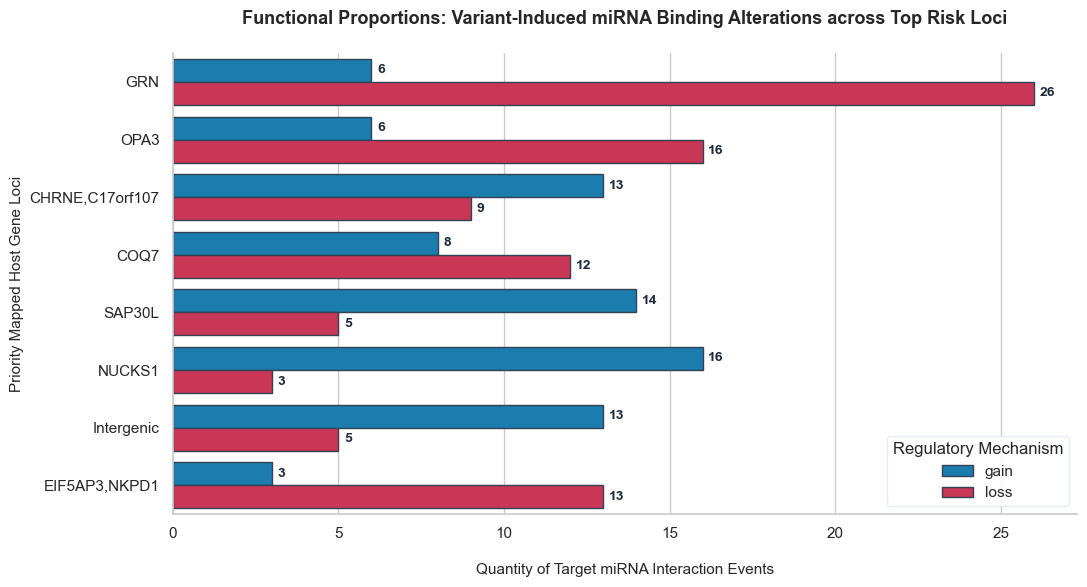

In [8]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 11})

top_genes = df_split['Gene_Name'].value_counts().head(8).index
df_vis = df_split[df_split['Gene_Name'].isin(top_genes)]

fig, ax = plt.subplots(figsize=(11, 6))

sns.countplot(
    data=df_vis,
    y='Gene_Name',
    hue=eff_col,
    order=top_genes,
    palette=['#0284c7', '#e11d48'], 
    edgecolor='#334155',
    lw=1,
    ax=ax
)

# Render numeric count markers on top of each bar for automated data transparency
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=4, color='#1e293b', fontweight='bold', fontsize=10)

ax.set_title("Functional Proportions: Variant-Induced miRNA Binding Alterations across Top Risk Loci\n", weight='bold', fontsize=13)
ax.set_xlabel("\nQuantity of Target miRNA Interaction Events", fontsize=11)
ax.set_ylabel("Priority Mapped Host Gene Loci", fontsize=11)
ax.legend(title="Regulatory Mechanism", loc='lower right', frameon=True, facecolor='white', edgecolor='#e2e8f0')

sns.despine()
plt.tight_layout()

# Export figure file to system path
plt.savefig("Thesis_Step3_Functional_Mechanism_Proportions.png", dpi=300, bbox_inches='tight')
print(" Figure successfully saved as 'Thesis_Step3_Functional_Mechanism_Proportions.png'")
plt.show()